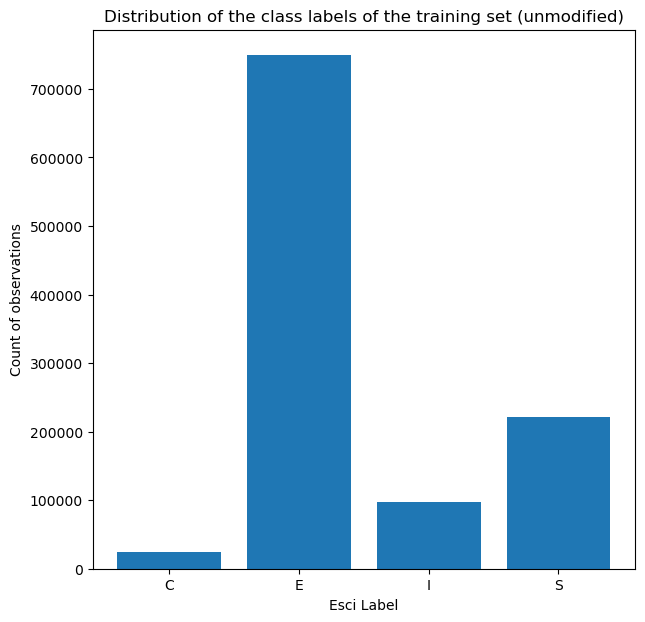

In [1]:
import numpy as np
import pandas as pd

Input_ids = pd.read_parquet("EmbeddedData/WordEmbedding_inputs.parquet")
Attention_masks = pd.read_parquet("EmbeddedData/WordEmbedding_attention.parquet")

from sklearn.model_selection import train_test_split
### Split data into training, validation and testing
# first, split into training:testing 80:20
# then, split training into training:validation 60:20 (in realtion to the entire data)
# ----> Training:Validation:Testing = 60:20:20
test_size = 0.2
val_size = 0.25

input_train, input_test, mask_train, mask_test = train_test_split(Input_ids, Attention_masks, test_size = test_size)
input_train, input_val, mask_train, mask_val = train_test_split(input_train, mask_train, test_size = val_size)



import matplotlib.pyplot as plt
def class_count_plot(y):
    """
    Look at the Esci label distribution for the training
    """
    classes, counts = np.unique(y, return_counts = True)
    fig = plt.figure(figsize = (7, 7))
    ax = fig.add_subplot()
    ax.bar(classes, counts)
    ax.set_title("Distribution of the class labels of the training set (unmodified)")
    ax.set_ylabel("Count of observations")
    ax.set_xlabel("Esci Label")
    plt.show()

class_count_plot(input_train.esci_label)

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


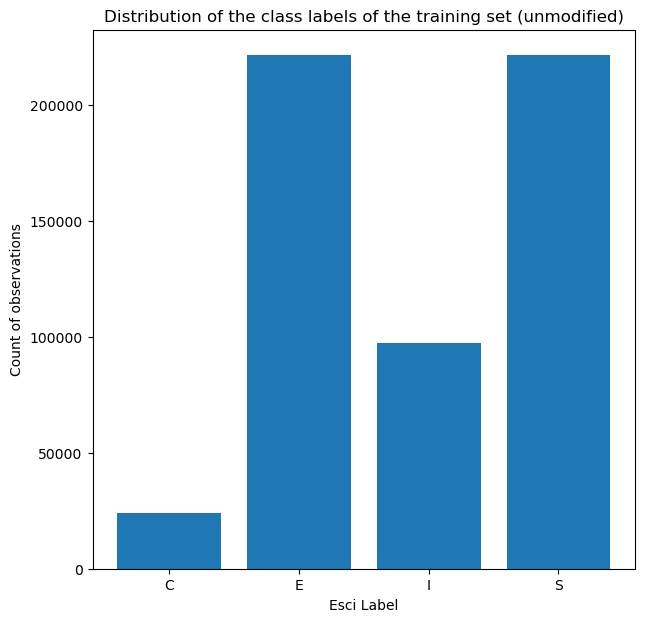

In [2]:
temp_input_columns = [f"input_{i}" for i in range(33*6+2)]
temp_mask_columns = [f"mask_{i}" for i in range(33*6+2)]

Input_ids_train = input_train.iloc[:, :33*6+2]
Input_ids_train.columns = temp_input_columns
Attention_masks_train = mask_train.iloc[:, :33*6+2]
Attention_masks_train.columns = temp_mask_columns
y_train = pd.DataFrame(input_train.iloc[:, -1])

x_train = pd.concat((Input_ids_train, Attention_masks_train), axis = 1)




### Either use SMOTE or NearMiss to even out the label distributions
from imblearn.under_sampling import NearMiss

sampling_dict = {
    "E" : np.sum(y_train == "S"), # only reduce the amount of EXACT matches to the amount of SUBSTITUTE matches. Making all counts euqal to the lowest class would discard way too many samples
    "S" : np.sum(y_train == "S"),
    "C" : np.sum(y_train == "C"),
    "I" : np.sum(y_train == "I")
}
nm = NearMiss(n_neighbors = 500, n_neighbors_ver3 = 500, sampling_strategy = sampling_dict)
x_train_resampled, y_train_resampled = nm.fit_resample(x_train, y_train)

class_count_plot(y_train_resampled)

In [3]:
Input_ids_train_resampled = x_train_resampled.iloc[:, :x_train_resampled.shape[1]//2]
Input_ids_train_resampled.columns = list(Input_ids.columns)[:33*6+2]
Attention_masks_train_resampled = x_train_resampled.iloc[:, x_train_resampled.shape[1]//2:].astype(int)
Attention_masks_train_resampled.columns = list(Attention_masks.columns)[:33*6+2]

In [4]:

y_train_resampled.to_parquet("EmbeddedData/WordEmbedding_esci_train.parquet")

Input_ids_train_resampled.to_parquet("EmbeddedData/WordEmbedding_inputs_train.parquet")
input_val.to_parquet("EmbeddedData/WordEmbedding_inputs_valid.parquet")
input_test.to_parquet("EmbeddedData/WordEmbedding_inputs_test.parquet")

Attention_masks_train_resampled.to_parquet("EmbeddedData/WordEmbedding_masks_train.parquet")
mask_val.to_parquet("EmbeddedData/WordEmbedding_masks_valid.parquet")
mask_test.to_parquet("EmbeddedData/WordEmbedding_masks_test.parquet")


## Save everything and upload it to google drive
## write the model and the training script

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pandas\io\parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\pandas\io\parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)
